# K-Means Clustering

Supponiamo di avere un e-coomerce, oppure addirittura un negozio fisico. K-Means è un algoritmo di clustering non supervisionato che può aiutarti a identificare il tuo cliente tipo analizzando e raggruppando i dati relativi ai tuoi clienti in base a caratteristiche comuni. Ad esempio, puoi utilizzare K-Means per:

1. **Segmentare i clienti**: Raggruppare i clienti in base a caratteristiche come età, localizzazione, preferenze di acquisto, frequenza e spesa media.
   
2. **Identificare cluster significativi**: Ogni gruppo (cluster) rappresenta un segmento omogeneo di clienti con comportamenti o caratteristiche simili.

3. **Personalizzare le strategie di marketing**: Una volta identificati i segmenti, puoi adattare le tue offerte e campagne pubblicitarie per soddisfare meglio le esigenze di ogni gruppo.



## Raggruppare i clienti in categorie

Se gestisci un e-commerce e usi dati come età, quantità di acquisti e valore medio, K-Means può suddividere i tuoi clienti in segmenti come giovani acquirenti occasionali, famiglie con acquisti ricorrenti e clienti premium ad alto valore. Da qui puoi sviluppare strategie mirate per ciascun gruppo.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('mall_customers.csv')
df = df.set_index('CustomerID')
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


### Proviamo a stampare un grafico 3d 🧨

Male o
Female ^


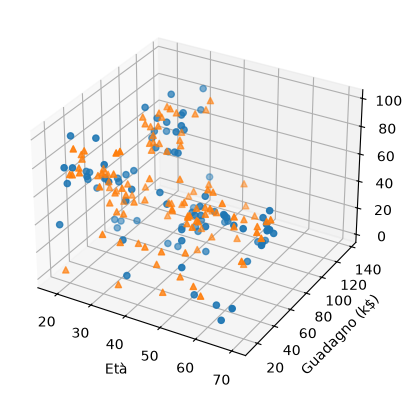

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

for sex, m in ['Male','o'] , ['Female','^']:
  print(sex,m)
  filtered_df = df.loc[df['Genre'] == sex]
  x = filtered_df['Age']
  y = filtered_df['Annual Income (k$)']
  z = filtered_df['Spending Score (1-100)']
  ax.scatter(x,y,z,marker=m)

plt.xlabel('Età')
plt.ylabel('Guadagno (k$)')
plt.show()

### Pre-processing

Utilizzeremo la codifica One-Hot per il **Gender** e lo `StandardScaler` per tutto il resto.

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_onehot = pd.get_dummies(df)

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_onehot)



df_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148, -1.12815215,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407, -1.12815215,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298,  0.88640526, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783,  0.88640526, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992,  0.88640526, -0.88640526]])

### Modello

Noi, sulla nostra variabile target, non sappiamo nulla. Proviamo ad assumere arbistrariamente che siano presenti 4 gruppi, e vediamo cosa succede.

In [4]:
model = KMeans(n_clusters=4, random_state=42)

model.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 5)","[

### Previsioni

I risultati del modello sono messi nella variabile `model.labels_`. Questo ci permette di aggiungere la colonna `Group` al nostro DataFrame.

In [5]:
df['Group'] = model.labels_
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Group
CustomerID,,,,,
1,Male,19,15,39,3
2,Male,21,15,81,3
3,Female,20,16,6,2
4,Female,23,16,77,1
5,Female,31,17,40,2


### Grafico in 3d con il colore che rappresenta i gruppi 🧨

Male o
Female ^


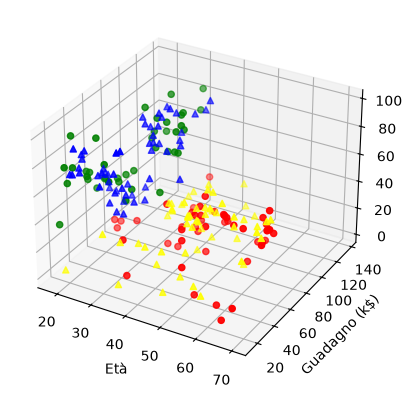

In [6]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

color_map = {
    0: 'red',
    1: 'blue',
    2: 'yellow',
    3: 'green'
}

for sex, m in ['Male','o'] , ['Female','^']:
  print(sex,m)
  filtered_df = df.loc[df['Genre'] == sex]
  x = filtered_df['Age']
  y = filtered_df['Annual Income (k$)']
  z = filtered_df['Spending Score (1-100)']
  colors = filtered_df['Group'].replace(color_map)
  ax.scatter(x,y,z,marker=m,c=colors)

plt.xlabel('Età')
plt.ylabel('Guadagno (k$)')
plt.show()

### Valutazione

Ha senso il nostro raggruppamento? Valutare un modello k-means non è così semplice. Essendo un modello unsupervised, non abbiamo una vera etichetta di riferimento con cui confrontare i risultati.

La cosa più semplice è verificare le medie dei vari gruppi, anche se questo approccio può essere limitato. Le medie forniscono un'indicazione generale delle caratteristiche centrali di ciascun cluster, ma non sempre sono rappresentative della distribuzione interna dei dati. Ad esempio, cluster con alta varianza potrebbero non essere ben descritti dalla media.

Detto questo, partiamo proprio dalle medie.

In [7]:
aggregate = df.groupby('Group')

print(aggregate.value_counts(['Genre']))
mean_result = df.groupby('Group')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(mean_result)

Group  Genre 
0      Male      48
1      Female    56
2      Female    56
3      Male      40
Name: count, dtype: int64
             Age  Annual Income (k$)  Spending Score (1-100)
Group                                                       
0      49.437500           62.416667               29.208333
1      28.392857           60.428571               68.178571
2      47.803571           58.071429               34.875000
3      28.250000           62.000000               71.675000


Le medie ci danno un risultato interessante. Volendo la nostra analisi potrebbe essere la seguente.

Chi viene a fare acquisti nel nostro negozio?

1. **Gruppi più giovani (1 e 3)**:
   - Entrambi i gruppi hanno un'età media di circa 28 anni.
   - I maschi del gruppo 3 mostrano un alto punteggio di spesa alto nonostante un reddito annuale nella media.
   - Le femmine del gruppo 1 hanno un reddito più alto ed un punteggio di spesa simile al gruppo femminile più adulto.

2. **Gruppi più adulti (0 e 2)**:
   - Il gruppo femminile (2) ha un punteggio di spesa moderato.
   - Il gruppo maschile (0) è il meno propenso a spendere, con un punteggio di spesa significativamente più basso rispetto agli altri gruppi.

Questa segmentazione può essere utile per sviluppare strategie di marketing o offerte mirate in base ai comportamenti e alle caratteristiche socioeconomiche di ciascun gruppo.

Tuttavia, possiamo utilizzare metriche come il silhouette score o il l'inertia (SSE).

In [8]:
model.score(df_scaled)

-386.82842558376666

Anche qua bisogna fare un appunto. Il numero di gruppi è scelto arbitrariamente. Possiamo tranquillamente dire che aumentando il numero di gruppi, aumenta la precisione del raggruppamento. Se, paradossalmente, decidiamo di usare 50 gruppi per un dataset di 50 campioni, avremmo un raggruppamento con errore nullo (per quanto perfettamente inutile).

In una situazione del genere si utilizza la cosiddetta **tecnica del gomito**. Questo metodo serve a trovare il numero ottimale di cluster in algoritmi come il K-means, tracciando un grafico tra il numero di cluster (K) e l'inertia, che misura la compattezza dei cluster. Il punto in cui la riduzione dell'inertia rallenta significativamente, formando un "gomito", rappresenta il numero ideale di cluster, bilanciando coerenza interna e complessità computazionale.

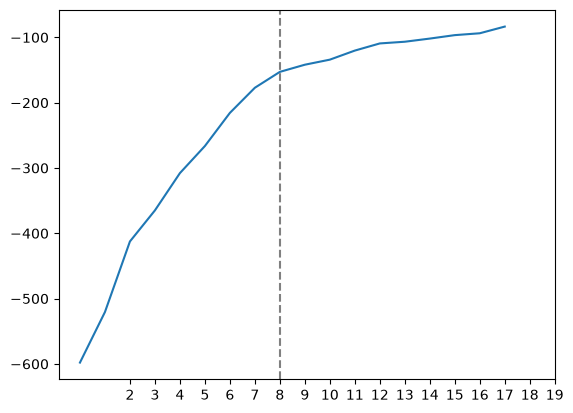

In [9]:
scores = []
for k in range(2,20):
  model = KMeans(n_clusters=k, random_state=808)
  model.fit(df_scaled)
  scores.append(model.score(df_scaled))

plt.plot(scores)
plt.xticks(range(2,20))
plt.axvline(x=8,ls='--',color='grey')
plt.show()


Sembrerebbe in questo caso che il numero di gruppi ottimale sia 8, quindi circa il doppio di quelli che abbiamo scelto. Quindi dobbiamo rifare tutto? No. Dobbiamo esplorare meglio la significatività dei dati che abbiamo ottenuto. Ad esempio, con alcuni boxplot!

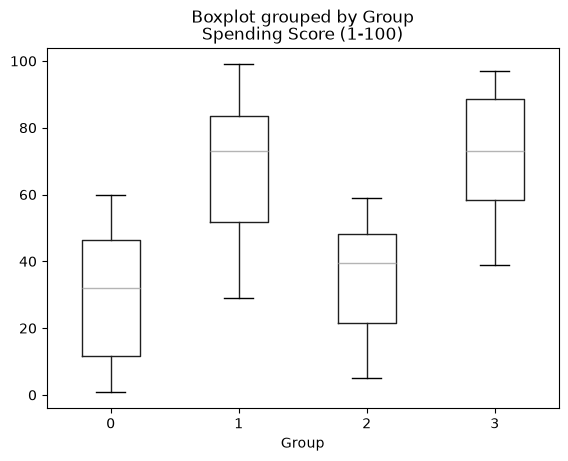

In [10]:
df.boxplot(column='Spending Score (1-100)',by='Group')
plt.grid(False)
plt.show()

## Attività

Cosa succede se non usiamo lo Standard Scaler? Qua sotto generiamo dei dati random per fare degli esperimenti. Confronta i risultati ottenuti con e senza l'uso dello Standard Scaler. Questo ci aiuterà a capire l'importanza della normalizzazione dei dati prima di applicare algoritmi di clustering come il k-means.

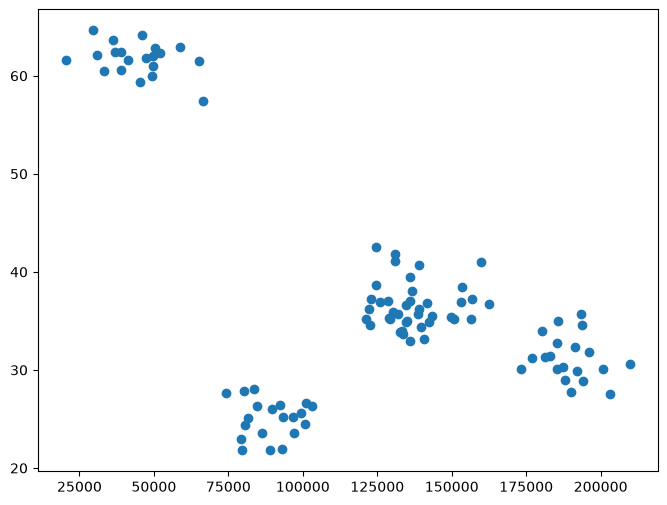

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale

np.random.seed(808)

# Questa funzione crea N campioni suddivisi in k gruppi

def createClusteredData(N, k):
    pointsPerCluster = float(N)/k
    X = []
    for i in range (k):
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        ageCentroid = np.random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
    X = np.array(X)
    return X


data = createClusteredData(100, 5)

plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1])
plt.show()